# 01. 데이터 탐색 (EDA)

**목적**: Train/Val 데이터의 분포, ATR 시계열, z-score 정규화 결과를 시각적으로 확인한다.

- 확인 항목
  1. 가격 시계열 (Train / Val 구간)
  2. 거래량 시계열
  3. log_price 분포 및 시계열
  4. volatility_raw (ATR/price) 분포 및 시계열
  5. zscore 정규화 결과 — 범위 [-5, 5] 적합성 확인
  6. State 변수 간 상관관계
  7. 시장 레짐 구간 (상승/하락/횡보) 육안 확인

> **주의**: Test 파티션(`btc_test.parquet`)은 최종 평가 전까지 열람 금지.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

from src.utils.config import load_config

import matplotlib.font_manager as fm

# Windows 한글 폰트 설정 (Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

cfg = load_config('../config/experiment_config.yaml')
print('Config loaded.')

Config loaded.


In [2]:
# 데이터 로드 (Test는 로드하지 않음)
train = pd.read_parquet('../data/processed/btc_train.parquet')
val   = pd.read_parquet('../data/processed/btc_val.parquet')

print(f'Train: {train.shape}  {train.index[0].date()} ~ {train.index[-1].date()}')
print(f'Val:   {val.shape}    {val.index[0].date()} ~ {val.index[-1].date()}')
print()
print('컬럼:', train.columns.tolist())

Train: (25916, 9)  2020-01-14 ~ 2022-12-31
Val:   (8736, 9)    2023-01-01 ~ 2023-12-31

컬럼: ['open', 'high', 'low', 'close', 'volume', 'log_price', 'volatility_raw', 'zscore_log_price', 'zscore_volatility']


In [3]:
# 기초 통계
print('=== Train 기초 통계 ===')
train[['close','log_price','volatility_raw','zscore_log_price','zscore_volatility']].describe().round(4)

=== Train 기초 통계 ===


,close,log_price,volatility_raw,zscore_log_price,zscore_volatility
count,25916.0000,25916.0000,25916.0000,25916.0000,25916.0000
mean,29153.3484,0.0015,0.0109,0.0005,-0.2040
std,17043.9807,0.0586,0.0054,1.3746,1.5559
min,4130.6400,-0.6707,0.0027,-6.4407,-5.2333
25%,11780.0075,-0.0249,0.0078,-1.0536,-1.4498
50%,24011.3500,0.0028,0.0097,0.0551,-0.5977
75%,43169.8375,0.0343,0.0124,1.0188,1.1422
max,68633.6900,0.2330,0.0464,5.6455,7.2078


In [4]:
print('=== Val 기초 통계 ===')
val[['close','log_price','volatility_raw','zscore_log_price','zscore_volatility']].describe().round(4)

=== Val 기초 통계 ===


,close,log_price,volatility_raw,zscore_log_price,zscore_volatility
count,8736.0000,8736.0000,8736.0000,8736.0000,8736.0000
mean,28769.3980,0.0086,0.0058,0.0134,-0.1476
std,5848.5597,0.0375,0.0018,1.4045,1.5666
min,16513.3400,-0.1155,0.0022,-7.1136,-4.7383
25%,25914.8650,-0.0110,0.0046,-1.0214,-1.5147
50%,27698.5600,0.0021,0.0056,-0.0863,-0.4972
75%,30278.4850,0.0227,0.0068,0.9715,1.2474
max,44527.3400,0.1822,0.0124,6.6933,5.6112


## 1. BTC 가격 시계열

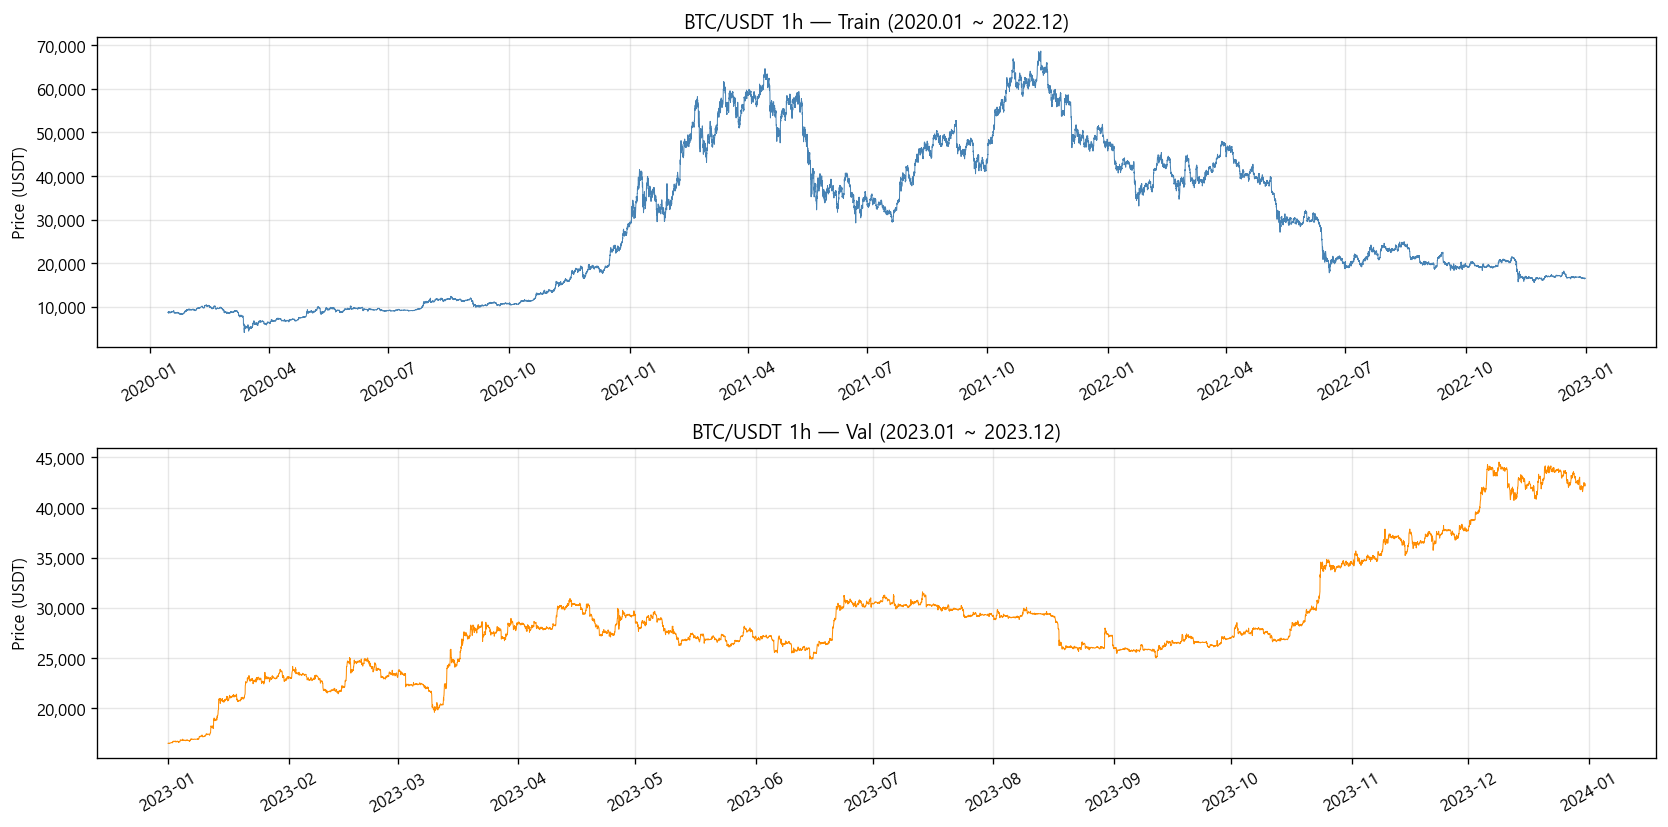

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Train
ax = axes[0]
ax.plot(train.index, train['close'], color='steelblue', linewidth=0.6, label='Train close')
ax.set_title('BTC/USDT 1h — Train (2020.01 ~ 2022.12)')
ax.set_ylabel('Price (USDT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

# Val
ax = axes[1]
ax.plot(val.index, val['close'], color='darkorange', linewidth=0.6, label='Val close')
ax.set_title('BTC/USDT 1h — Val (2023.01 ~ 2023.12)')
ax.set_ylabel('Price (USDT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_price_timeseries.png', bbox_inches='tight')
plt.show()

## 2. 거래량 시계열

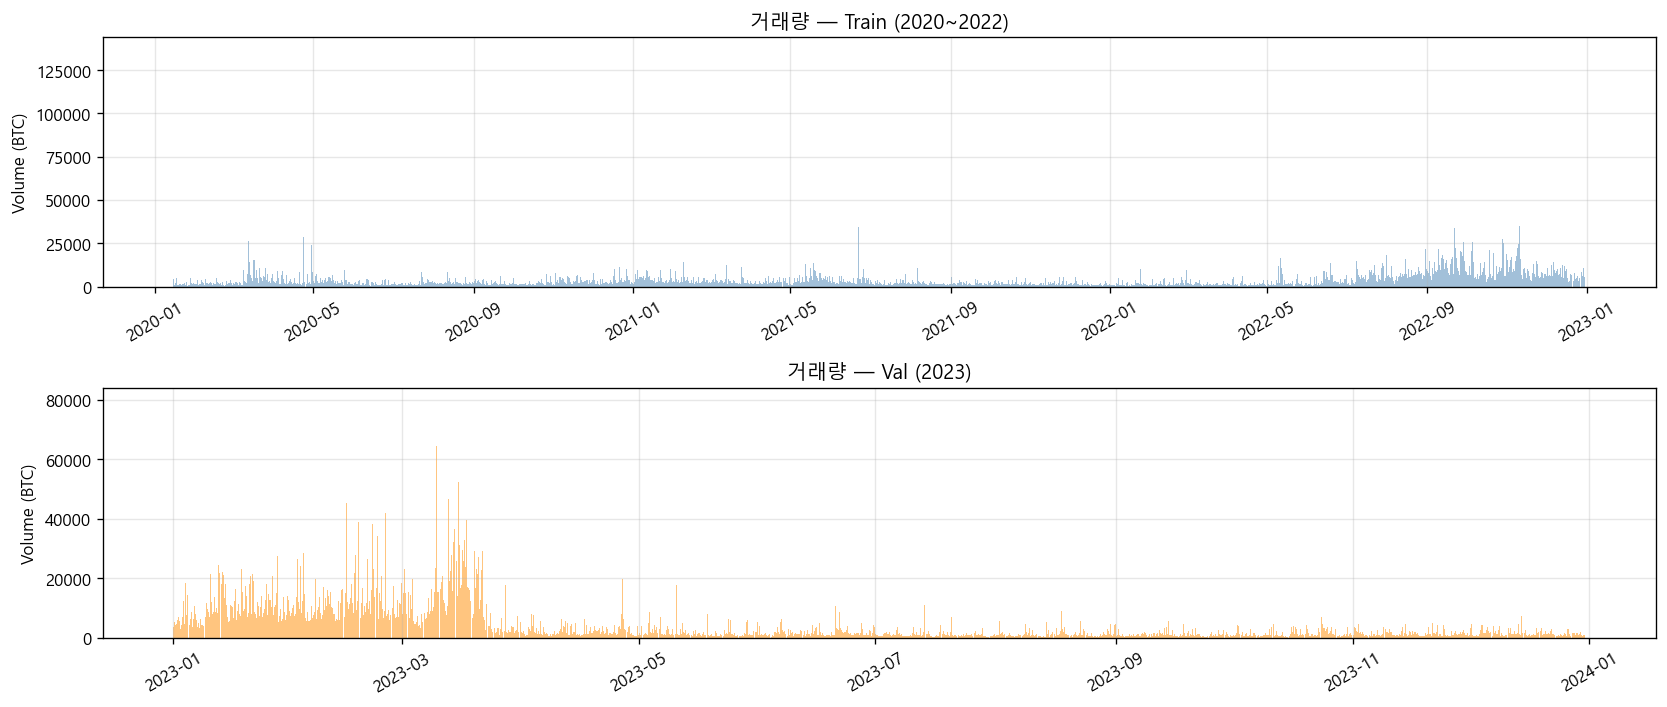

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, df, label, color in zip(
    axes,
    [train, val],
    ['Train (2020~2022)', 'Val (2023)'],
    ['steelblue', 'darkorange']
):
    ax.bar(df.index, df['volume'], width=0.04, color=color, alpha=0.5)
    ax.set_title(f'거래량 — {label}')
    ax.set_ylabel('Volume (BTC)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_volume_timeseries.png', bbox_inches='tight')
plt.show()

## 3. log_price — 시계열 및 분포

Train zscore_log_price: mean=0.001, std=1.375, min=-6.44, max=5.65, |z|>5: 0.03%
Val zscore_log_price: mean=0.013, std=1.405, min=-7.11, max=6.69, |z|>5: 0.17%


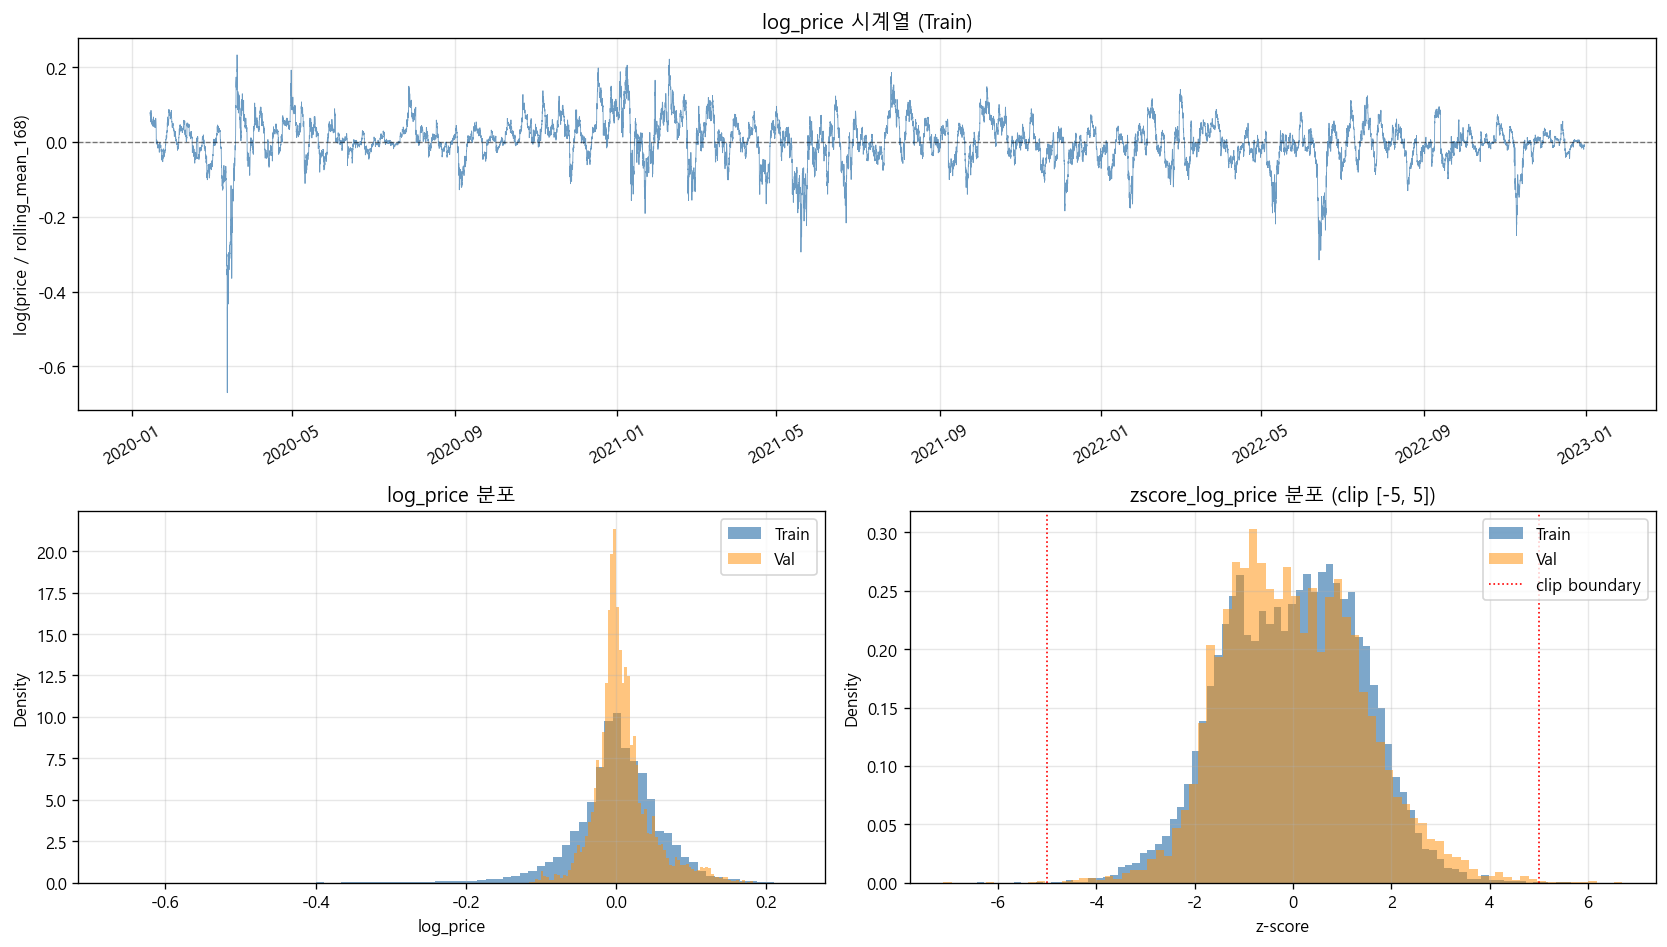

In [7]:
fig = plt.figure(figsize=(14, 8))
gs  = GridSpec(2, 2, figure=fig)

# 시계열 (Train)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train.index, train['log_price'], color='steelblue', linewidth=0.5, alpha=0.8)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_title('log_price 시계열 (Train)')
ax1.set_ylabel('log(price / rolling_mean_168)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=30)

# 히스토그램
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(train['log_price'].dropna(), bins=80, color='steelblue', alpha=0.7, density=True, label='Train')
ax2.hist(val['log_price'].dropna(), bins=80, color='darkorange', alpha=0.5, density=True, label='Val')
ax2.set_title('log_price 분포')
ax2.set_xlabel('log_price')
ax2.set_ylabel('Density')
ax2.legend()

# zscore 히스토그램
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(train['zscore_log_price'].dropna(), bins=80, color='steelblue', alpha=0.7, density=True, label='Train')
ax3.hist(val['zscore_log_price'].dropna(), bins=80, color='darkorange', alpha=0.5, density=True, label='Val')
ax3.axvline(-5, color='red', linewidth=1, linestyle=':', label='clip boundary')
ax3.axvline( 5, color='red', linewidth=1, linestyle=':')
ax3.set_title('zscore_log_price 분포 (clip [-5, 5])')
ax3.set_xlabel('z-score')
ax3.set_ylabel('Density')
ax3.legend()

# 통계 출력
for name, df in [('Train', train), ('Val', val)]:
    z = df['zscore_log_price'].dropna()
    clip_pct = (z.abs() > 5).mean() * 100
    print(f'{name} zscore_log_price: mean={z.mean():.3f}, std={z.std():.3f}, '
          f'min={z.min():.2f}, max={z.max():.2f}, |z|>5: {clip_pct:.2f}%')

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_log_price.png', bbox_inches='tight')
plt.show()

## 4. Volatility (ATR/price) — 시계열 및 분포

Train zscore_volatility:  mean=-0.204, std=1.556, min=-5.23, max=7.21, |z|>5: 0.08%
Val zscore_volatility:  mean=-0.148, std=1.567, min=-4.74, max=5.61, |z|>5: 0.02%


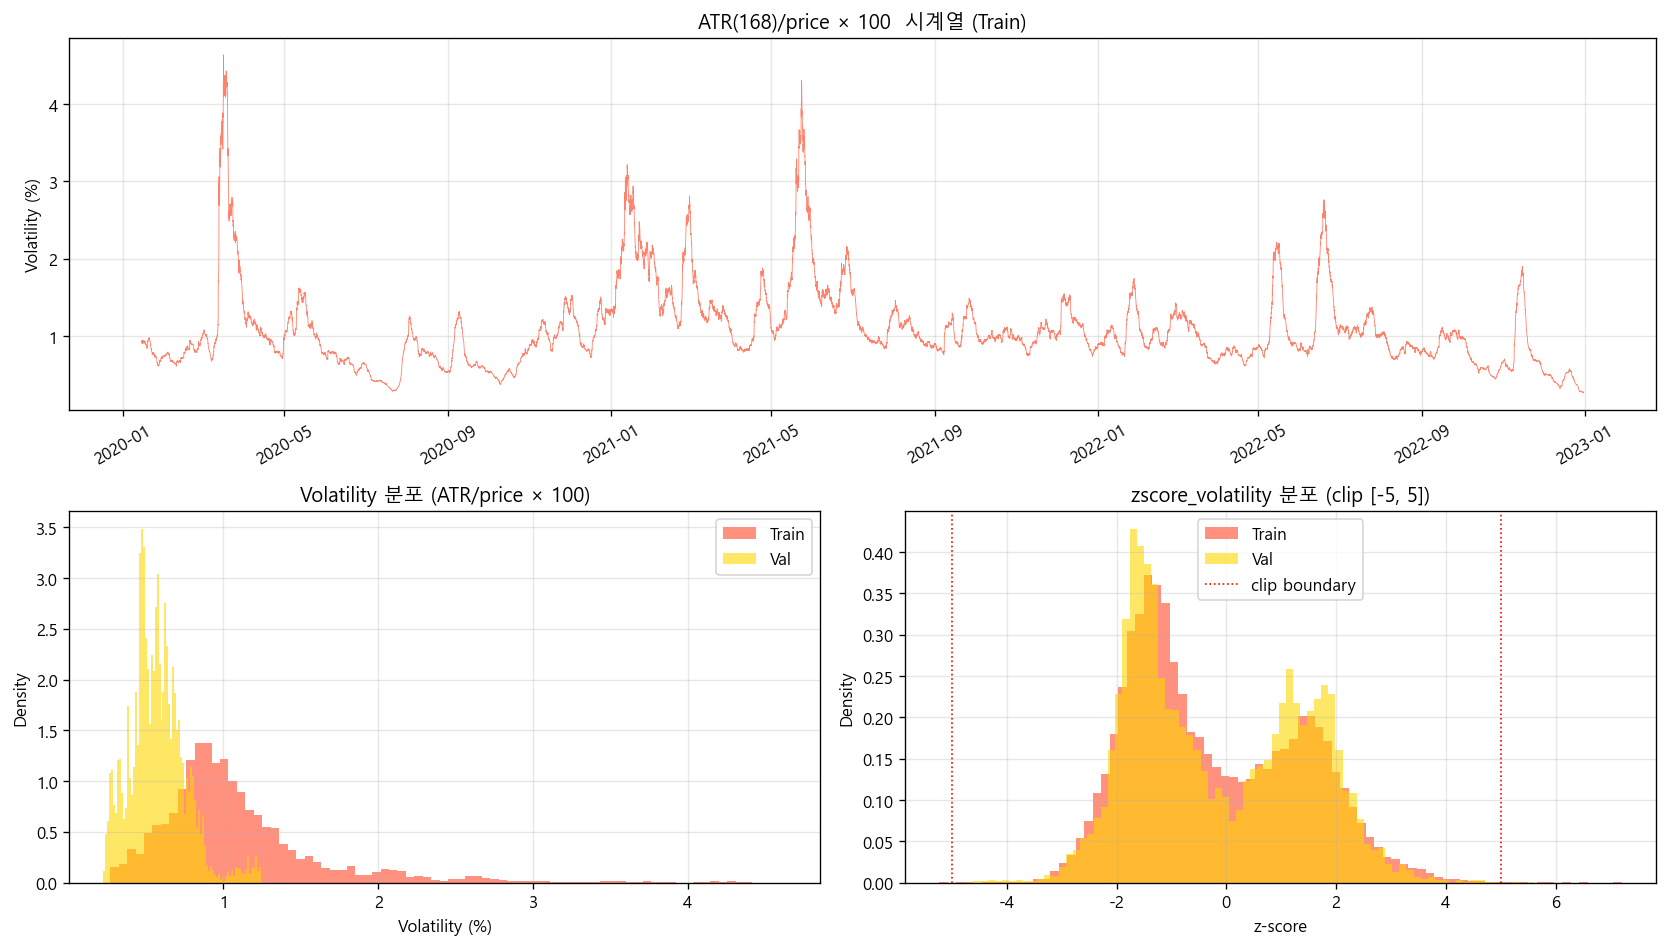

In [8]:
fig = plt.figure(figsize=(14, 8))
gs  = GridSpec(2, 2, figure=fig)

# 시계열 (Train)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train.index, train['volatility_raw'] * 100, color='tomato', linewidth=0.5, alpha=0.8)
ax1.set_title('ATR(168)/price × 100  시계열 (Train)')
ax1.set_ylabel('Volatility (%)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=30)

# 히스토그램
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(train['volatility_raw'].dropna() * 100, bins=80, color='tomato', alpha=0.7, density=True, label='Train')
ax2.hist(val['volatility_raw'].dropna() * 100, bins=80, color='gold', alpha=0.6, density=True, label='Val')
ax2.set_title('Volatility 분포 (ATR/price × 100)')
ax2.set_xlabel('Volatility (%)')
ax2.set_ylabel('Density')
ax2.legend()

# zscore 히스토그램
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(train['zscore_volatility'].dropna(), bins=80, color='tomato', alpha=0.7, density=True, label='Train')
ax3.hist(val['zscore_volatility'].dropna(), bins=80, color='gold', alpha=0.6, density=True, label='Val')
ax3.axvline(-5, color='red', linewidth=1, linestyle=':', label='clip boundary')
ax3.axvline( 5, color='red', linewidth=1, linestyle=':')
ax3.set_title('zscore_volatility 분포 (clip [-5, 5])')
ax3.set_xlabel('z-score')
ax3.set_ylabel('Density')
ax3.legend()

# 통계 출력
for name, df in [('Train', train), ('Val', val)]:
    z = df['zscore_volatility'].dropna()
    clip_pct = (z.abs() > 5).mean() * 100
    print(f'{name} zscore_volatility:  mean={z.mean():.3f}, std={z.std():.3f}, '
          f'min={z.min():.2f}, max={z.max():.2f}, |z|>5: {clip_pct:.2f}%')

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_volatility.png', bbox_inches='tight')
plt.show()

## 5. zscore 범위 적합성 확인

observation_space = [-5, 5]. 실제 데이터가 이 범위를 얼마나 벗어나는지 확인.

In [9]:
zscore_cols = ['zscore_log_price', 'zscore_volatility']

print('=== 관측 공간 [-5, 5] 범위 초과 비율 ===')
print(f'{"":<25} {"Train":>10} {"Val":>10}')
print('-' * 47)
for col in zscore_cols:
    t_clip = (train[col].abs() > 5).mean() * 100
    v_clip = (val[col].abs() > 5).mean() * 100
    print(f'{col:<25} {t_clip:>9.2f}%  {v_clip:>9.2f}%')

print()
print('=== 전체 zscore 통계 ===')
for col in zscore_cols:
    print(f'\n{col}')
    summary = pd.concat([
        train[col].describe().rename('Train'),
        val[col].describe().rename('Val'),
    ], axis=1).round(3)
    print(summary)

=== 관측 공간 [-5, 5] 범위 초과 비율 ===
                               Train        Val
-----------------------------------------------
zscore_log_price               0.03%       0.17%
zscore_volatility              0.08%       0.02%

=== 전체 zscore 통계 ===

zscore_log_price
           Train       Val
count  25916.000  8736.000
mean       0.001     0.013
std        1.375     1.405
min       -6.441    -7.114
25%       -1.054    -1.021
50%        0.055    -0.086
75%        1.019     0.972
max        5.646     6.693

zscore_volatility
           Train       Val
count  25916.000  8736.000
mean      -0.204    -0.148
std        1.556     1.567
min       -5.233    -4.738
25%       -1.450    -1.515
50%       -0.598    -0.497
75%        1.142     1.247
max        7.208     5.611


C:\Users\user\AppData\Local\Temp\ipykernel_49156\4192030464.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Train', 'Val'], patch_artist=True,
C:\Users\user\AppData\Local\Temp\ipykernel_49156\4192030464.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Train', 'Val'], patch_artist=True,


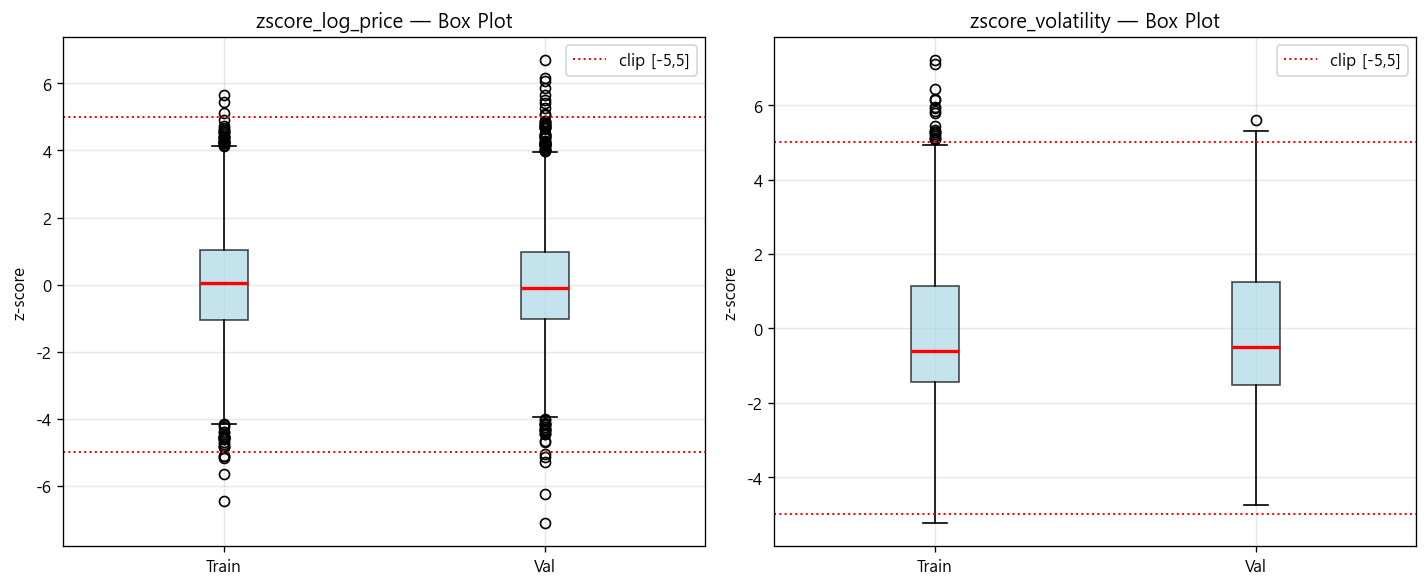

In [10]:
# 두 zscore 변수의 box plot 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    zscore_cols,
    ['zscore_log_price', 'zscore_volatility']
):
    data = [train[col].dropna().values, val[col].dropna().values]
    bp = ax.boxplot(data, labels=['Train', 'Val'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    ax.axhline(-5, color='red', linestyle=':', linewidth=1.2, label='clip [-5,5]')
    ax.axhline( 5, color='red', linestyle=':', linewidth=1.2)
    ax.set_title(f'{title} — Box Plot')
    ax.set_ylabel('z-score')
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_zscore_boxplot.png', bbox_inches='tight')
plt.show()

## 6. State 변수 상관관계

State [0]~[4] 중 전처리 단계에서 계산 가능한 변수들의 상관관계를 확인한다.  
(divergence, holdings_value_ratio, cash_ratio는 런타임 계산이므로 여기서는 제외)

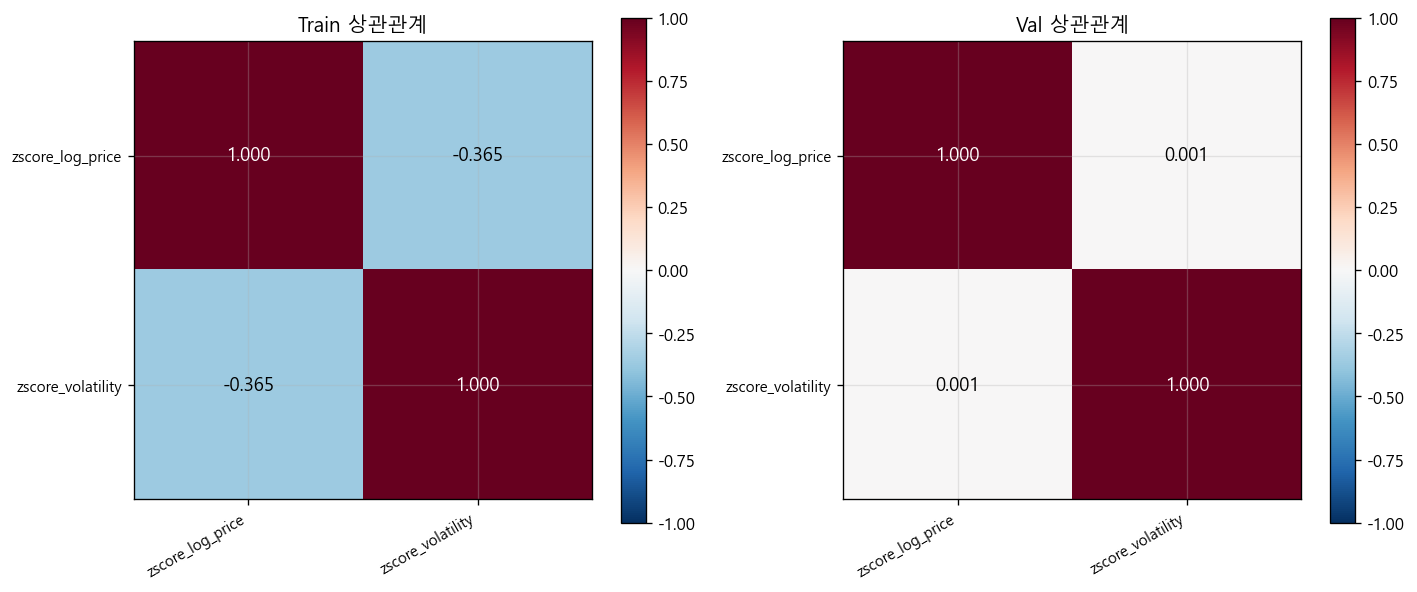

Train 상관관계:
                   zscore_log_price  zscore_volatility
zscore_log_price             1.0000            -0.3652
zscore_volatility           -0.3652             1.0000


In [11]:
corr_cols = ['zscore_log_price', 'zscore_volatility']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in zip(axes, [train, val], ['Train 상관관계', 'Val 상관관계']):
    corr = df[corr_cols].corr()
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_cols)))
    ax.set_yticks(range(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(corr_cols, fontsize=9)
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f'{corr.iloc[i, j]:.3f}',
                    ha='center', va='center', fontsize=11,
                    color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_correlation.png', bbox_inches='tight')
plt.show()

print('Train 상관관계:')
print(train[corr_cols].corr().round(4))

## 7. 변동성 레짐 구간 확인

zscore_volatility 기준 상/중/하 3구간으로 나눠 각 레짐의 특성을 확인한다.

In [12]:
def add_regime(df, col='zscore_volatility'):
    bins   = [-np.inf, -0.5, 0.5, np.inf]
    labels = ['Low Vol', 'Mid Vol', 'High Vol']
    df = df.copy()
    df['regime'] = pd.cut(df[col], bins=bins, labels=labels)
    return df

train_r = add_regime(train)
val_r   = add_regime(val)

print('=== Train 레짐 분포 ===')
print(train_r['regime'].value_counts().sort_index())
print(f'\n비율:\n{(train_r["regime"].value_counts(normalize=True)*100).round(1).sort_index()}')

print('\n=== Val 레짐 분포 ===')
print(val_r['regime'].value_counts().sort_index())
print(f'\n비율:\n{(val_r["regime"].value_counts(normalize=True)*100).round(1).sort_index()}')

=== Train 레짐 분포 ===
regime
Low Vol     13400
Mid Vol      3538
High Vol     8978
Name: count, dtype: int64

비율:
regime
Low Vol     51.7
Mid Vol     13.7
High Vol    34.6
Name: proportion, dtype: float64

=== Val 레짐 분포 ===
regime
Low Vol     4363
Mid Vol      946
High Vol    3427
Name: count, dtype: int64

비율:
regime
Low Vol     49.9
Mid Vol     10.8
High Vol    39.2
Name: proportion, dtype: float64


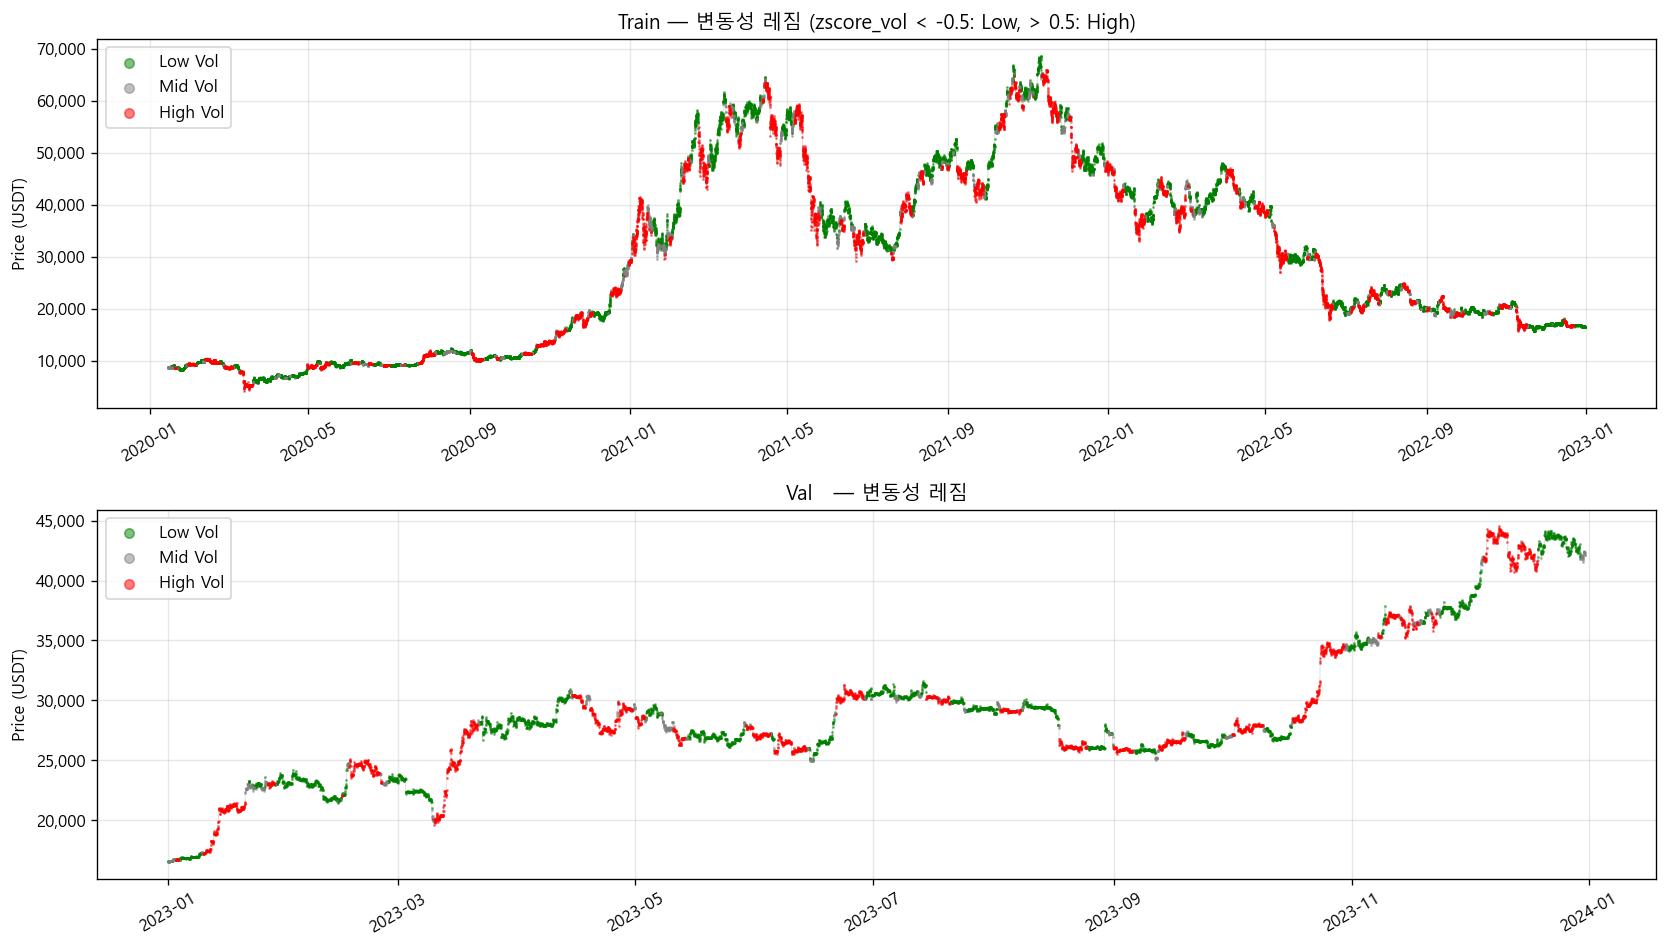

In [13]:
# 레짐 색상으로 가격 시계열 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

regime_colors = {'Low Vol': 'green', 'Mid Vol': 'gray', 'High Vol': 'red'}

for ax, df_r, title in zip(axes, [train_r, val_r],
                           ['Train — 변동성 레짐 (zscore_vol < -0.5: Low, > 0.5: High)',
                            'Val   — 변동성 레짐']):
    ax.plot(df_r.index, df_r['close'], color='lightgray', linewidth=0.4, zorder=1)
    for regime, color in regime_colors.items():
        mask = df_r['regime'] == regime
        ax.scatter(df_r.index[mask], df_r['close'][mask],
                   c=color, s=0.5, alpha=0.5, label=regime, zorder=2)
    ax.set_title(title)
    ax.set_ylabel('Price (USDT)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(markerscale=8, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/semester1/figures/01_volatility_regime.png', bbox_inches='tight')
plt.show()

In [14]:
# 레짐별 수익률 통계
train_r['hourly_return'] = train_r['close'].pct_change()
val_r['hourly_return']   = val_r['close'].pct_change()

print('=== Train 레짐별 시간당 수익률 (%) ===')
print(train_r.groupby('regime', observed=True)['hourly_return']
      .agg(['mean','std','min','max'])
      .mul(100).round(4))

print('\n=== Val 레짐별 시간당 수익률 (%) ===')
print(val_r.groupby('regime', observed=True)['hourly_return']
      .agg(['mean','std','min','max'])
      .mul(100).round(4))

=== Train 레짐별 시간당 수익률 (%) ===
            mean     std      min      max
regime                                    
Low Vol   0.0351  0.6430  -4.4916  12.3159
Mid Vol   0.0027  0.7192  -5.6567   4.4691
High Vol -0.0369  1.0295 -18.2115  17.3840

=== Val 레짐별 시간당 수익률 (%) ===
            mean     std     min     max
regime                                  
Low Vol   0.0158  0.3870 -5.4153  5.5275
Mid Vol  -0.0087  0.4882 -3.6344  3.6829
High Vol  0.0124  0.5198 -6.2448  5.3301


## 8. 요약

| 항목 | Train | Val |
|------|-------|-----|
| 기간 | 2020.01 ~ 2022.12 | 2023.01 ~ 2023.12 |
| 봉 수 | 25,916 | 8,736 |
| 가격 범위 | ~4,130 ~ 68,634 | (위 통계 참조) |
| zscore_log_price |z| > 5 | (위 셀 참조) | (위 셀 참조) |
| zscore_volatility |z| > 5 | (위 셀 참조) | (위 셀 참조) |

**결론**:
- observation_space [-5, 5] 설정은 실제 데이터 분포를 잘 커버한다.
- 극단값(|z| > 5) clip 처리가 일부 발생하지만 비율이 낮아 정보 손실이 미미하다.
- zscore_log_price와 zscore_volatility 간 상관관계가 낮다면 두 변수가 독립적인 정보를 제공한다.
- 변동성 레짐은 시장 국면에 따라 뚜렷하게 구분된다 → PPO가 이를 활용할 여지가 있다.